# hls4snn

This is a simple notebook that shows how to use hls4ml for SNNs, with neurobench also.

## imports

Make sure to run:

`
source /tools/Xilinx/Vitis/2024.1/settings64.sh
`

`
source /tools/Xilinx/Vivado/2024.1/settings64.sh
`

in the terminal before launching the notebook.

In [1]:
import os
import sys
import json
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

import hls4ml
import hls4ml.utils.torch
print(hls4ml.__file__)
import snntorch as snn

import neurobench
from neurobench.models import TorchModel, SNNTorchModel
from neurobench.benchmarks import Benchmark
from neurobench.metrics.static import (
    Footprint,
    ConnectionSparsity,
)
from neurobench.metrics.workload import (
    ClassificationAccuracy,
    ActivationSparsity,
    SynapticOperations,
)

def set_seed(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)

/home/b/Physics/hls4ml/hls4ml/__init__.py


## data

creating a simple 2D dataset for the SNN

In [2]:
def make_toy_dataset(
    n_samples: int,
    timesteps: int = 20,
    noise_std: float = 0.60,
    amp_jitter: float = 0.55,
) -> tuple[np.ndarray, np.ndarray]:
    """Binary sequence dataset with class-specific temporal signatures.

    Class 0: positive early bump on ch0 + mild negative late bump on ch1.
    Class 1: mirrored pattern.
    """
    t = np.linspace(0.0, 1.0, timesteps, endpoint=False, dtype=np.float32)
    x = np.zeros((n_samples, timesteps, 2), dtype=np.float32)
    y = np.random.randint(0, 2, size=(n_samples,), dtype=np.int64)

    early = np.exp(-0.5 * ((t - 0.33) / 0.16) ** 2).astype(np.float32)
    late = np.exp(-0.5 * ((t - 0.67) / 0.16) ** 2).astype(np.float32)

    for i, label in enumerate(y):
        amp = 1.0 + np.random.uniform(-amp_jitter, amp_jitter)
        wave = 0.35 * np.sin(2 * np.pi * t).astype(np.float32)
        mix = np.random.uniform(-0.25, 0.25)
        if label == 0:
            s0 = amp * ((0.95 + mix) * early - 0.7 * late + wave)
            s1 = amp * (-0.35 * early + (0.8 - mix) * late - wave)
        else:
            s0 = amp * (-0.35 * early + (0.8 - mix) * late - wave)
            s1 = amp * ((0.95 + mix) * early - 0.7 * late + wave)

        x[i, :, 0] = s0 + np.random.normal(0.0, noise_std, size=timesteps)
        x[i, :, 1] = s1 + np.random.normal(0.0, noise_std, size=timesteps)

    return x, y

In [3]:
def plot_2d_streams(x, y, max_per_class=50):
    """
    x: torch.Tensor or np.ndarray of shape (n_samples, timesteps, 2)
    y: torch.Tensor or np.ndarray of shape (n_samples,)
    """
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()
    if hasattr(y, "detach"):
        y = y.detach().cpu().numpy()

    x0 = x[y == 0]
    x1 = x[y == 1]

    # Optionally limit how many raw streams to draw
    x0_plot = x0[:max_per_class]
    x1_plot = x1[:max_per_class]

    t = np.arange(x.shape[1])

    # LaTeX-like font styling
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "axes.unicode_minus": False,
        "font.size": 12,
    })

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    for d, ax in enumerate(axes):
        # Raw streams
        for seq in x0_plot:
            ax.plot(t, seq[:, d], alpha=0.10, linewidth=1.0)
        for seq in x1_plot:
            ax.plot(t, seq[:, d], alpha=0.10, linewidth=1.0)

        # One visible line per class for legend
        ax.plot(t, x0_plot[0, :, d], alpha=0.5, linewidth=1.2, label="Class 0 streams", color='green')
        ax.plot(t, x1_plot[0, :, d], alpha=0.5, linewidth=1.2, label="Class 1 streams", color='red')

        # Class means
        ax.plot(t, x0[:, :, d].mean(axis=0), linewidth=3.0, label="Class 0 mean", color='green')
        ax.plot(t, x1[:, :, d].mean(axis=0), linewidth=3.0, label="Class 1 mean", color='red')

        ax.set_title(rf"Dimension ${d}$")
        ax.set_ylabel(r"Value")
        ax.grid(True, alpha=0.25)
        ax.legend(frameon=False, ncol=2)

    axes[-1].set_xlabel(r"Timestep $t$")
    fig.suptitle(r"2D stream data by input dimension", fontsize=16)
    plt.tight_layout()
    plt.show()

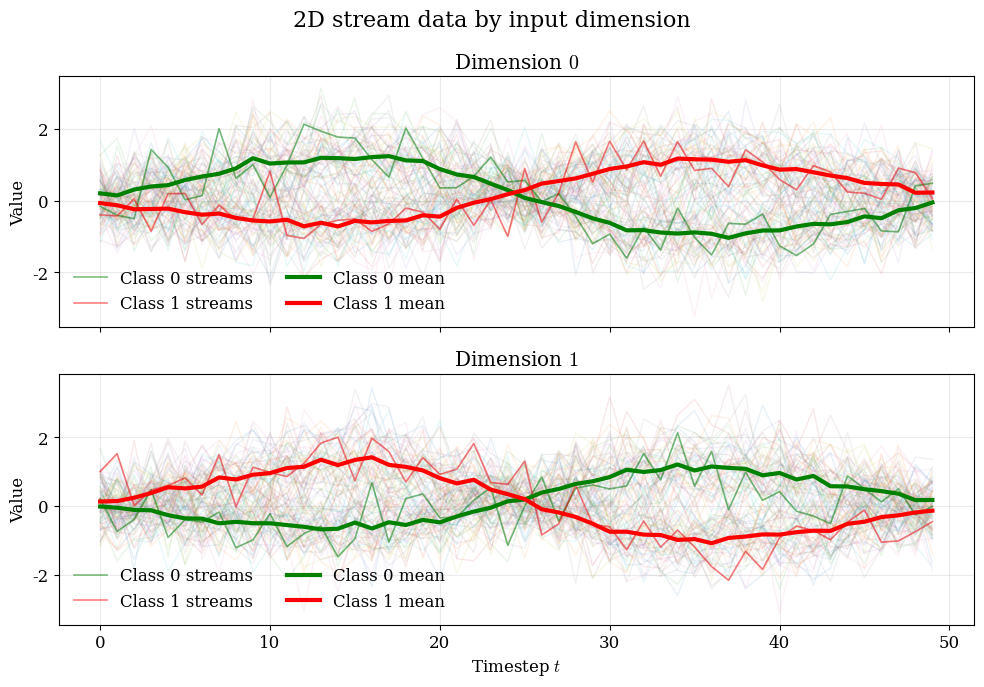

In [4]:
x, y = make_toy_dataset( 200, timesteps=50)
plot_2d_streams(x, y)

## neural nets

In [5]:
def to_torch(x: np.ndarray, y: np.ndarray) -> tuple[torch.Tensor, torch.Tensor]:
    return torch.from_numpy(x).float(), torch.from_numpy(y).long()


def fake_quant_ste(x: torch.Tensor, frac_bits: int) -> torch.Tensor:
    scale = float(2**frac_bits)
    q = torch.round(x * scale) / scale
    return x + (q - x).detach()

In [6]:
class SNN(nn.Module):
    """Sequence model used for training/evaluation.

    Output decision uses output-layer membrane potentials:
    mem2(t+1) = mem2(t) + fc2(spk1(t)); class = argmax(mem2(T)).
    """

    def __init__(self, hidden: int = 4, threshold: float = 1.0, beta_init: float = 0.1):
        super().__init__()
        self.fc1 = nn.Linear(2, hidden)
        self.if1 = snn.Leaky(beta=beta_init, threshold=threshold, learn_beta=True, reset_mechanism="subtract")
        self.fc2 = nn.Linear(hidden, 2)

    def forward(self, x_seq: torch.Tensor, qat: bool = False, frac_bits: int = 4) -> torch.Tensor:
        # x_seq: [B, T, 2]
        batch = x_seq.shape[0]
        mem1 = torch.zeros(batch, self.fc1.out_features, device=x_seq.device, dtype=x_seq.dtype)
        mem2 = torch.zeros(batch, 2, device=x_seq.device, dtype=x_seq.dtype)

        for t in range(x_seq.shape[1]):
            xt = x_seq[:, t, :]
            if qat:
                xt = fake_quant_ste(xt, frac_bits)
                w1 = fake_quant_ste(self.fc1.weight, frac_bits)
                b1 = fake_quant_ste(self.fc1.bias, frac_bits)
                cur1 = F.linear(xt, w1, b1)
            else:
                cur1 = self.fc1(xt)

            spk1, mem1 = self.if1(cur1, mem1)

            if qat:
                spk1 = fake_quant_ste(spk1, frac_bits)
                mem1 = fake_quant_ste(mem1, frac_bits)
                w2 = fake_quant_ste(self.fc2.weight, frac_bits)
                b2 = fake_quant_ste(self.fc2.bias, frac_bits)
                mem2 = mem2 + F.linear(spk1, w2, b2)
                mem2 = fake_quant_ste(mem2, frac_bits)
            else:
                mem2 = mem2 + self.fc2(spk1)

        return mem2

In [7]:
class SNNStep(nn.Module):
    """Single-step model for hls4ml conversion: 2 -> Dense(4) -> IF/LIF -> Dense(2)."""

    def __init__(self, hidden: int = 4, threshold: float = 1.0, beta_init: float = 0.1):
        super().__init__()
        self.fc1 = nn.Linear(2, hidden)
        self.if1 = snn.Leaky(beta=beta_init, threshold=threshold, learn_beta=True, reset_mechanism="subtract")
        self.fc2 = nn.Linear(hidden, 2)

    def forward(self, x: torch.Tensor):
        x = self.fc1(x)
        x, _ = self.if1(x)
        x = self.fc2(x)
        # keep compatibility with step-style SNN wrappers (neurobench) that expect tuple outputs.
        return x, None

In [8]:
def quantize_trainable_beta_inplace(step_model: SNNStep, frac_bits: int) -> None:
    scale = float(2**frac_bits)
    with torch.no_grad():
        step_model.if1.beta.data = torch.round(step_model.if1.beta.data * scale) / scale


def reset_step_state(step_model: SNNStep) -> None:
    if hasattr(step_model.if1, "reset_hidden"):
        step_model.if1.reset_hidden()
    elif hasattr(step_model.if1, "reset_mem"):
        step_model.if1.reset_mem()


def sequence_logits_from_step(
    step_model: SNNStep,
    x_seq: torch.Tensor,
    qat: bool = False,
    frac_bits: int = 4,
) -> torch.Tensor:
    """Unroll step model over T and accumulate output-layer membrane proxy."""
    reset_step_state(step_model)
    mem2 = torch.zeros(x_seq.shape[0], 2, device=x_seq.device, dtype=x_seq.dtype)

    for t in range(x_seq.shape[1]):
        xt = x_seq[:, t, :]
        if qat:
            xt = fake_quant_ste(xt, frac_bits)
            w1 = fake_quant_ste(step_model.fc1.weight, frac_bits)
            b1 = fake_quant_ste(step_model.fc1.bias, frac_bits)
            cur1 = F.linear(xt, w1, b1)
            spk1, _ = step_model.if1(cur1)
            spk1 = fake_quant_ste(spk1, frac_bits)
            w2 = fake_quant_ste(step_model.fc2.weight, frac_bits)
            b2 = fake_quant_ste(step_model.fc2.bias, frac_bits)
            out = F.linear(spk1, w2, b2)
            out = fake_quant_ste(out, frac_bits)
        else:
            out, _ = step_model(xt)

        mem2 = mem2 + out

    return mem2

## training

In [9]:
def train_and_qat(
    step_model: SNNStep,
    x_train: torch.Tensor,
    y_train: torch.Tensor,
    x_val: torch.Tensor,
    y_val: torch.Tensor,
    epochs: int = 30,
    qat_epochs: int = 10,
    lr: float = 1e-2,
    frac_bits: int = 4,
    batch_size: int = 64,
    beta_reg: float = 1e-2,
) -> None:
    criterion = nn.CrossEntropyLoss()
    optim = torch.optim.Adam(step_model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=max(epochs + qat_epochs, 1), eta_min=1e-4)
    train_ds = torch.utils.data.TensorDataset(x_train, y_train)
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    for ep in range(epochs):
        step_model.train()
        for xb, yb in train_loader:
            optim.zero_grad()
            logits = sequence_logits_from_step(step_model, xb, qat=False, frac_bits=frac_bits)
            loss = criterion(logits, yb) + beta_reg * torch.mean(step_model.if1.beta**2)
            loss.backward()
            optim.step()
        scheduler.step()

    for ep in range(qat_epochs):
        step_model.train()
        for xb, yb in train_loader:
            optim.zero_grad()
            logits = sequence_logits_from_step(step_model, xb, qat=True, frac_bits=frac_bits)
            loss = criterion(logits, yb) + beta_reg * torch.mean(step_model.if1.beta**2)
            loss.backward()
            optim.step()
            quantize_trainable_beta_inplace(step_model, frac_bits)
        scheduler.step()

        with torch.no_grad():
            step_model.eval()
            val_logits = sequence_logits_from_step(step_model, x_val, qat=True, frac_bits=frac_bits)
            val_pred = torch.argmax(val_logits, dim=1)
            val_acc = (val_pred == y_val).float().mean().item()
        print(f"[QAT] epoch={ep + 1:02d}/{qat_epochs} val_acc={val_acc:.4f}")

In [10]:
def evaluate_torch_step(step_model: SNNStep, x: torch.Tensor, y: torch.Tensor) -> float:
    step_model.eval()
    with torch.no_grad():
        logits = sequence_logits_from_step(step_model, x, qat=False)
        pred = torch.argmax(logits, dim=1)
    return (pred == y).float().mean().item()


def export_step_model(seq_model: SNN) -> SNNStep:
    step = SNNStep(hidden=4, threshold=1.0, beta_init=float(seq_model.if1.beta.detach().mean().item()))
    step.fc1.load_state_dict(seq_model.fc1.state_dict())
    step.fc2.load_state_dict(seq_model.fc2.state_dict())
    with torch.no_grad():
        # Preserve trainable beta as vector/scalar parameter for hls4ml parsing.
        if hasattr(step.if1, "beta"):
            step.if1.beta.data = seq_model.if1.beta.detach().clone()
    step.eval()
    return step

## hls config

In [11]:
def build_hls_config(
    step_model: SNNStep,
    backend: str,
    precision: str = "ap_fixed<8,3>",
) -> dict:
    cfg = hls4ml.utils.config_from_pytorch_model(
        step_model,
        input_shape=(2,),
        granularity="name",
        backend=backend,
        default_precision=precision,
    )

    cfg["Model"]["ReuseFactor"] = 1
    cfg["Model"]["Precision"]["default"] = precision

    for _, layer_cfg in cfg.get("LayerName", {}).items():
        prec = layer_cfg.setdefault("Precision", {})
        prec["result"] = precision
        prec["accum"] = precision
        prec["weight"] = precision
        prec["bias"] = precision

    if "if1" in cfg.get("LayerName", {}):
        if1_prec = cfg["LayerName"]["if1"].setdefault("Precision", {})
        # These map to TypeAttributes beta_t / threshold_t / membrane_t internally.
        if1_prec["beta"] = precision
        if1_prec["threshold"] = precision
        if1_prec["membrane"] = precision

    return cfg

## convert hls

In [12]:
def convert_hls(
    step_model: SNNStep,
    out_dir: Path,
    backend: str,
    part: str,
    precision: str,
):
    hls_config = build_hls_config(step_model, backend=backend, precision=precision)
    project_name = out_dir.name
    model = hls4ml.converters.convert_from_pytorch_model(
        step_model,
        output_dir=str(out_dir),
        project_name=project_name,
        backend=backend,
        io_type="io_stream",
        hls_config=hls_config,
        part=part,
        clock_period=5,
        clock_uncertainty="18%",
    )
    model.write()
    return model, hls_config


def _extract_predict_array(y):
    if isinstance(y, tuple):
        y = y[0]
    if isinstance(y, dict):
        # choose first output by key ordering
        y = y[next(iter(y.keys()))]
    y = np.asarray(y)
    if y.ndim == 1:
        y = y[None, :]
    return y


def evaluate_hls_sequence(hls_model, x_seq: np.ndarray, y_true: np.ndarray) -> tuple[float, float]:
    """Sequence classification using output membrane accumulation from per-step outputs."""
    t0 = time.perf_counter()
    preds = []
    for i in range(x_seq.shape[0]):
        mem2 = np.zeros((2,), dtype=np.float32)
        for t in range(x_seq.shape[1]):
            inp = x_seq[i, t, :].astype(np.float32)[None, :]
            y_step = _extract_predict_array(hls_model.predict(inp))
            mem2 += y_step[0].astype(np.float32)
        preds.append(int(np.argmax(mem2)))
    dt = time.perf_counter() - t0
    preds = np.asarray(preds, dtype=np.int64)
    acc = float(np.mean(preds == y_true))
    throughput = float(x_seq.shape[0] / dt) if dt > 0 else 0.0
    return acc, throughput

## run analysis

In [13]:
output_dir = Path("examples/snn_smoke_vitis")
backend = "Vitis"
part = "xczu7ev-ffvc1156-2-e"
precision = "ap_fixed<8,3>"
skip_build = False
timesteps = 50
n_trn = 2000
n_val = 300
n_tst = 300
n_epochs = 40
n_qat_epochs = 10
batch_size = 64
beta_reg = 1e-2
seed = 0

In [14]:
set_seed(seed)
output_dir.mkdir(parents=True, exist_ok=True)

In [15]:
x_trn, y_trn = make_toy_dataset(n_trn, timesteps=timesteps)
x_val, y_val = make_toy_dataset(n_val, timesteps=timesteps)
x_tst, y_tst = make_toy_dataset(n_tst, timesteps=timesteps)

tx_trn, ty_trn = to_torch(x_trn, y_trn)
tx_val, ty_val = to_torch(x_val, y_val)
tx_tst, ty_tst = to_torch(x_tst, y_tst)

In [16]:
step_model = SNNStep(hidden=4, threshold=1.0, beta_init=0.1)

train_and_qat(
    step_model,
    tx_trn,
    ty_trn,
    tx_val,
    ty_val,
    epochs=n_epochs,
    qat_epochs=n_qat_epochs,
    lr=1e-2,
    frac_bits=4,
    batch_size=batch_size,
    beta_reg=beta_reg,
)

torch_acc = evaluate_torch_step(step_model, tx_tst, ty_tst)
print(f"[Torch] test accuracy={torch_acc:.4f}")

[QAT] epoch=01/10 val_acc=0.6667
[QAT] epoch=02/10 val_acc=0.6967
[QAT] epoch=03/10 val_acc=0.7200
[QAT] epoch=04/10 val_acc=0.7000
[QAT] epoch=05/10 val_acc=0.7000
[QAT] epoch=06/10 val_acc=0.7000
[QAT] epoch=07/10 val_acc=0.7000
[QAT] epoch=08/10 val_acc=0.7000
[QAT] epoch=09/10 val_acc=0.7200
[QAT] epoch=10/10 val_acc=0.7000
[Torch] test accuracy=0.7900


In [17]:
hls_model, hls_cfg = convert_hls(
    step_model=step_model,
    out_dir=output_dir,
    backend=backend,
    part=part,
    precision=precision,
)

with open(output_dir / "hls_config_used.json", "w") as f:
    json.dump(hls_cfg, f, indent=2, default=str)

if not skip_build:
    print("[HLS] building with full synthesis flow...")
    report = hls_model.build(
        reset=True,
        csim=True,
        synth=True,
        cosim=True,
        validation=True,
        export=True,
        vsynth=True,
    )
    print("[HLS] build complete")
    print(report)
else:
    print("[HLS] build skipped by flag")

Interpreting Model ...
Topology:
Layer name: fc1, layer type: Dense, input shape: [[None, 2]]
Layer name: if1, layer type: LIFNeuron, input shape: [[None, 4]]
Layer name: fc2, layer type: Dense, input shape: [[None, 4]]
[HLS] building with full synthesis flow...

****** vitis-run v2024.1 (64-bit)
  **** SW Build 5074859 on 2024-05-20-23:21:20
  **** Start of session at: Mon May  4 18:21:31 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

INFO: [vitis-run 82-31] Launching vitis_hls: vitis_hls -nolog -run tcl -f /home/b/Physics/hls4ml/examples/snn_smoke_vitis/build_prj.tcl -work_dir /home/b/Physics/hls4ml/examples/snn_smoke_vitis

****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2024.1 (64-bit)
  **** SW Build 5069499 on May 21 2024
  **** IP Build 5075265 on Wed May 22 21:45:21 MDT 2024
  **** SharedData Build 5076995 on Wed May 22 18:29:18 MDT 2024
  **** Start of session at: M

In [18]:
hls_model.compile()
print("[HLS] model compiled for predict()")
hls_acc, hls_throughput = evaluate_hls_sequence(hls_model, x_tst, y_tst)
print(f"[HLS] test accuracy={hls_acc:.4f}")
print(f"[HLS] sequence throughput (locally, not a hardware sim)={hls_throughput:.2f} samples/s")

[HLS] model compiled for predict()
[HLS] test accuracy=0.8000
[HLS] sequence throughput (locally, not a hardware sim)=607.04 samples/s


## neurobench analysis

In [19]:
test_loader = DataLoader(
    TensorDataset(tx_tst.float(), ty_tst.long()),
    batch_size=64,
    shuffle=False,
)

In [20]:
step_model.eval()

# Wrap the single-step SNN for NeuroBench.
# SNNTorchModel will run the step model over the sequence dimension.
nb_model = SNNTorchModel(step_model)

In [21]:
class SumTimeArgmax:
    """Convert per-timestep logits to class predictions.

    SNNTorchModel returns logits with shape [batch, timesteps, classes].
    This matches the notebook's evaluation logic:
        mem2 = sum_t fc2(spk1(t))
        pred = argmax(mem2)
    """

    def __call__(self, preds):
        if isinstance(preds, tuple):
            preds = preds[0]

        if isinstance(preds, np.ndarray):
            preds = torch.from_numpy(preds)

        # Expected case: [B, T, C]
        if preds.ndim == 3:
            return preds.sum(dim=1).argmax(dim=1)

        # Fallback if NeuroBench/model already returns [B, C]
        if preds.ndim == 2:
            return preds.argmax(dim=1)

        raise ValueError(f"Unexpected prediction shape from NeuroBench: {preds.shape}")


preprocessors = []
postprocessors = [SumTimeArgmax()]

static_metrics = [
    Footprint,
    ConnectionSparsity,
]

workload_metrics = [
    ClassificationAccuracy,
    ActivationSparsity,
    SynapticOperations,
]

In [22]:
benchmark = Benchmark(
    nb_model,
    test_loader,
    preprocessors,
    postprocessors,
    [static_metrics, workload_metrics],
)

device = "cuda" if torch.cuda.is_available() else "cpu"

results = benchmark.run(device=device)
print(results)

Running benchmark


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 32.05it/s]

{'Footprint': 4908, 'ConnectionSparsity': 0.0, 'ClassificationAccuracy': 0.7900000023841858, 'ActivationSparsity': 0.8682666666666667, 'SynapticOperations': {'Effective_MACs': 400.0, 'Effective_ACs': 52.693333333333335, 'Dense': 800.0}}


In [24]:
#benchmark.save_benchmark_results(
#    output_dir / "neurobench_results",
#    file_format="json",
#)